#### Heart beat anomaly detector - autoencoder neural network model

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, roc_curve, RocCurveDisplay, auc

import keras

In [43]:
# Zadanie 1

path = "ECG5000.csv"

rows = []
with open(path, "r") as f:
    for line in f.readlines():
        data, _, label = line.partition(":")
        row = {i: float(val) for i, val in enumerate(data.split(","))}
        row["type"] = int(label.strip())
        rows.append(row)

df = pd.DataFrame(rows)


In [44]:
# Split dataset with 7/3 ratio, then create two subsets normal and anomaly with dropped label
X_train, X_test = train_test_split(df, test_size=0.3, random_state=42)

X_train_normal = X_train.loc[X_train["type"] == 1].drop(labels=["type"], axis=1)
X_train_anom = X_train.loc[X_train["type"] != 1].drop(labels=["type"], axis=1)

X_test_normal = X_test.loc[X_test["type"] == 1].drop(labels=["type"], axis=1)
X_test_anom = X_test.loc[X_test["type"] != 1].drop(labels=["type"], axis=1)

In [45]:
scaler = MinMaxScaler()

X_train_combined = np.concatenate([X_train_normal, X_train_anom])

scaler.fit(X_train_combined)

X_train_normal = scaler.transform(X_train_normal)
X_train_anom = scaler.transform(X_train_anom)

X_test_normal = scaler.transform(X_test_normal)
X_test_anom = scaler.transform(X_test_anom)

In [46]:
# Zadanie 2

shape = X_train_normal.shape[1:]

# Encoder
input = keras.layers.Input(shape=shape, name="Input")

enc_first = keras.layers.Dense(128, activation="relu", name="Encoder_first")(input)
enc_dropout_first = keras.layers.Dropout(rate=0.05)(enc_first)

enc_second = keras.layers.Dense(64, activation="relu", name="Encoder_second")(enc_dropout_first)
enc_dropout_second = keras.layers.Dropout(rate=0.05)(enc_second)

enc_third = keras.layers.Dense(32, activation="relu", name="Encoder_third")(enc_dropout_second)
enc_fourth = keras.layers.Dense(8, activation="relu", name="Encoder_fourth")(enc_third)

encoder = keras.Model(input, enc_fourth, name="Encoder")
encoder.summary()

# Decoder
dec_input = keras.layers.Input(shape=(8,), name="Decoder_input")

dec_first = keras.layers.Dense(32, activation="relu", name="Decoder_second")(dec_input)
dec_dropout_first = keras.layers.Dropout(rate=0.05)(dec_first)

dec_second = keras.layers.Dense(64, activation="relu", name="Decoder_third")(dec_dropout_first)
dec_dropout_second = keras.layers.Dropout(rate=0.05)(dec_second)

dec_third = keras.layers.Dense(128, activation="relu", name="Decoder_fourth")(dec_dropout_second)
dec_fourth = keras.layers.Dense(X_train_normal.shape[1], activation="sigmoid", name="Decoder_fifth")(dec_third)

output = keras.layers.Reshape(shape, name="Output")(dec_fourth)

decoder = keras.Model(dec_input, output, name="Decoder")
decoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_first (Dense)           │ (None, 128)            │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_second (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_third (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_fourth (Dense)          │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,648 (111.91 KB)

 Trainable params: 28,648 (111.91 KB)

 Non-trainable params: 0 (0.00 B)

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Decoder_input (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_second (Dense)          │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_third (Dense)           │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_fourth (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_fifth (Dense)           │ (None, 140)            │        18,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Reshape)                │ (None, 140)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,780 (112.42 KB)

 Trainable params: 28,780 (112.42 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
autoencoder = keras.Model(input, decoder(encoder(input)), name='Autoencoder')

lr = 1e-4
opt = keras.optimizers.AdamW(learning_rate=lr)
autoencoder.compile(optimizer=opt, loss='mse')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 8)              │        28,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 140)            │        28,780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,428 (224.33 KB)

 Trainable params: 57,428 (224.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0294 - val_loss: 0.0259 - learning_rate: 1.0000e-04
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0254 - val_loss: 0.0218 - learning_rate: 1.0000e-04
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0211 - val_loss: 0.0167 - learning_rate: 1.0000e-04
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0166 - val_loss: 0.0117 - learning_rate: 1.0000e-04
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0129 - val_loss: 0.0084 - learning_rate: 1.0000e-04
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - val_loss: 0.0067 - learning_rate: 1.0000e-04
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0099 - val_loss: 0.0061 - learning_rate: 1.0000e-04
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0095 - val_loss: 0.0057 - learning_rate: 1.0000e-04
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0091 - val_loss: 0.0056 - 

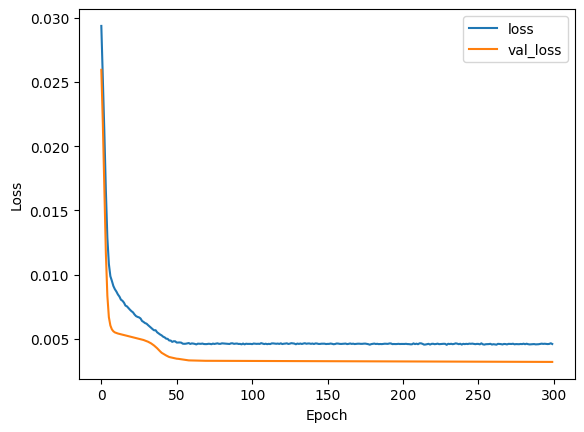

In [48]:
# Zadanie 3

# Start training
n_epochs = 300
batch_size = 128

# Fit only normal traffic training data, so model learns how to recreate it properly.
# Then compute recreation error to distinct anomalies from normal traffic based on specific threshold.
fit = autoencoder.fit(
    X_train_normal, X_train_normal, 
    epochs=n_epochs, 
    batch_size=batch_size, 
    validation_data=(X_test_normal, X_test_normal),
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
)

# Display training on the plot
plt.plot(fit.history['loss'], label='loss')
plt.plot(fit.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


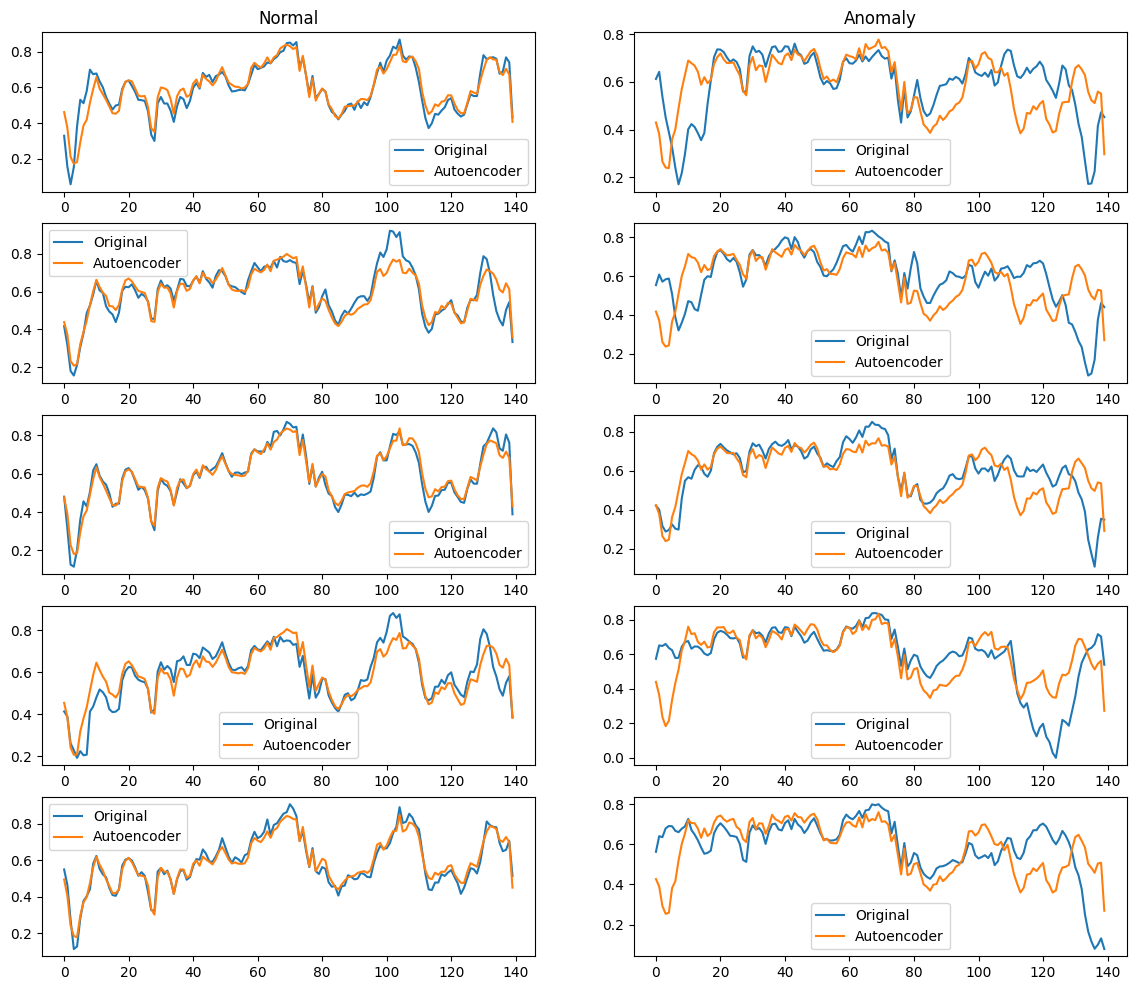

In [49]:
# Zadanie 4

X_train_normal_decoded = autoencoder.predict(X_train_normal, batch_size=batch_size)
X_train_anom_decoded = autoencoder.predict(X_train_anom, batch_size=batch_size)

X_test_normal_decoded = autoencoder.predict(X_test_normal, batch_size=batch_size)
X_test_anom_decoded = autoencoder.predict(X_test_anom, batch_size=batch_size)


num_signals = 5
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
axes[0, 0].set_title("Normal")
axes[0, 1].set_title("Anomaly")
for i in range(num_signals):
    # normal
    sns.lineplot(data=X_train_normal[i], ax=axes[i, 0], label="Original")
    sns.lineplot(data=X_train_normal_decoded[i], ax=axes[i, 0], label="Autoencoder")
    # anomaly
    sns.lineplot(data=X_train_anom[i], ax=axes[i, 1], label="Original")
    sns.lineplot(data=X_train_anom_decoded[i], ax=axes[i, 1], label="Autoencoder")


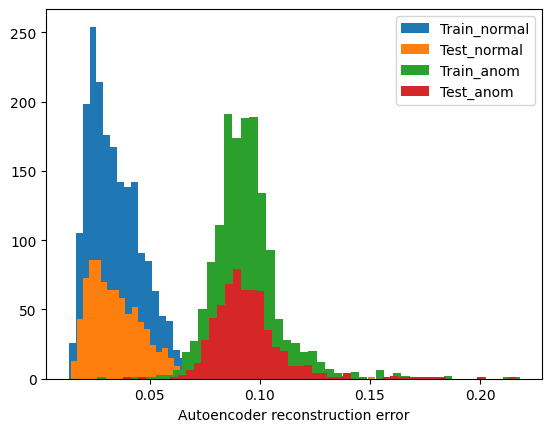

In [50]:
train_normal_re = np.mean(np.abs(X_train_normal - X_train_normal_decoded), axis=1)
test_normal_re = np.mean(np.abs(X_test_normal - X_test_normal_decoded), axis=1)

train_anom_re = np.mean(np.abs(X_train_anom - X_train_anom_decoded), axis=1)
test_anom_re = np.mean(np.abs(X_test_anom - X_test_anom_decoded), axis=1)

plt.hist(train_normal_re, bins=50, label='Train_normal')
plt.hist(test_normal_re, bins=50, label='Test_normal')
plt.hist(train_anom_re, bins=50, label='Train_anom')
plt.hist(test_anom_re, bins=50, label='Test_anom')
plt.xlabel('Autoencoder reconstruction error')
plt.legend()
plt.show()

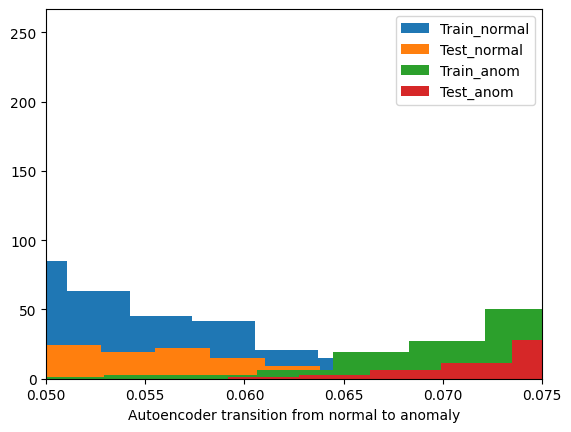

In [51]:
plt.hist(train_normal_re, bins=50, label='Train_normal')
plt.hist(test_normal_re, bins=50, label='Test_normal')
plt.hist(train_anom_re, bins=50, label='Train_anom')
plt.hist(test_anom_re, bins=50, label='Test_anom')
plt.xlim(0.050, 0.075)
plt.xlabel('Autoencoder transition from normal to anomaly')
plt.legend()
plt.show()

# Transition happens around 0.065 and 0.070

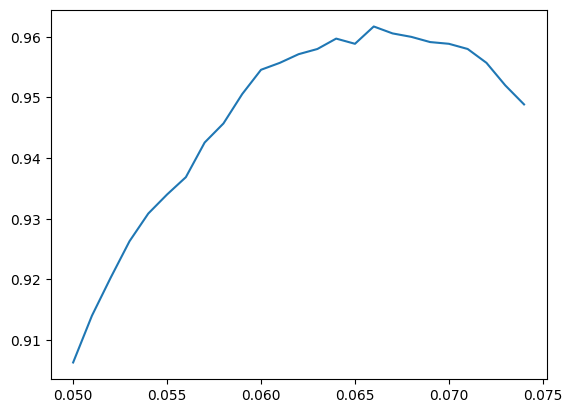

Best accuracy:  0.9617142857142857
Threshold:  0.06600000000000002


In [52]:
train_re_combined = np.concatenate([train_normal_re, train_anom_re])
labels_train = [0]*len(train_normal_re) + [1]*len(train_anom_re)

best_acc = 0
acc_vals = []

for threshold in np.arange(0.050, 0.075, 0.001):
    acc = accuracy_score(y_pred=(train_re_combined > threshold).astype(int), y_true=labels_train)
    acc_vals.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

plt.plot(np.arange(0.050, 0.075, 0.001), acc_vals)
plt.show()

print("Best accuracy: ", best_acc)
print("Threshold: ", best_threshold)
    

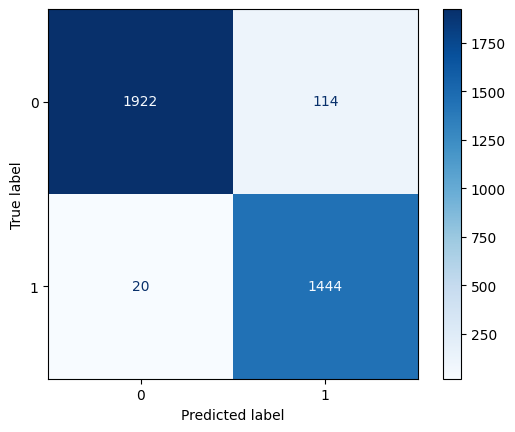

In [53]:
# Train set confusion matrix
train_pred_labels = [
    0 if best_threshold > pred_re else 1 for pred_re in train_re_combined 
]

cm_preds_network = confusion_matrix(y_true=labels_train, y_pred=train_pred_labels)
disp_train_cm = ConfusionMatrixDisplay(cm_preds_network)
disp_train_cm.plot(cmap="Blues")

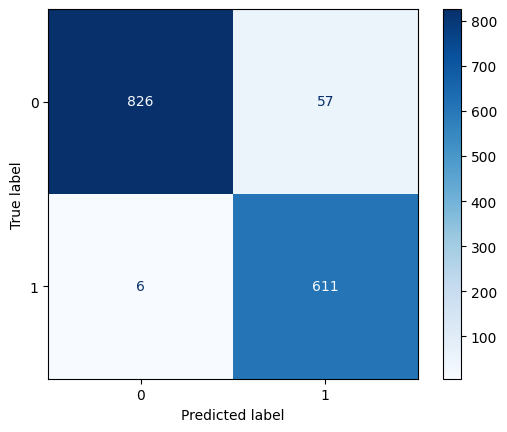

In [54]:
# Test set confusion matrix

test_re_combined = np.concatenate([test_normal_re, test_anom_re])
labels_test = [0]*len(test_normal_re) + [1]*len(test_anom_re)

test_pred_labels = [
    0 if best_threshold > pred_re else 1 for pred_re in test_re_combined 
]

cm_preds_network = confusion_matrix(y_true=labels_test, y_pred=test_pred_labels)
disp_train_cm = ConfusionMatrixDisplay(cm_preds_network)
disp_train_cm.plot(cmap="Blues")

For this task we want to maximize recall - the sensitivity for anomaly class. Minimizing false negatives ratio (missing real anomaly).

In [57]:
metrics = {
    "acc_train": accuracy_score(y_true=labels_train, y_pred=train_pred_labels),
    "acc_test": accuracy_score(y_true=labels_test, y_pred=test_pred_labels),
    "recall_train": recall_score(y_true=labels_train, y_pred=train_pred_labels),
    "recall_test": recall_score(y_true=labels_test, y_pred=test_pred_labels),
    "precission_train": precision_score(y_true=labels_train, y_pred=train_pred_labels),
    "presission_test": precision_score(y_true=labels_test, y_pred=test_pred_labels),
    "f1_train": f1_score(y_true=labels_train, y_pred=train_pred_labels),
    "f1_test": f1_score(y_true=labels_test, y_pred=test_pred_labels),
}

for key, val in metrics.items():
    print(f"{key}: {val}")

acc_train: 0.9617142857142857
acc_test: 0.958
recall_train: 0.9863387978142076
recall_test: 0.9902755267423015
precission_train: 0.926829268292683
presission_test: 0.9146706586826348
f1_train: 0.9556585043017869
f1_test: 0.9509727626459143


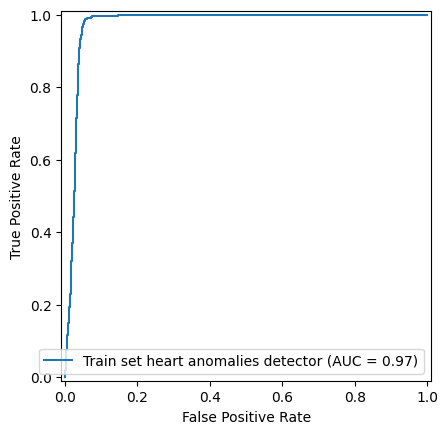

In [64]:
# ROC AUC for train set
fpr, tpr, thresholds = roc_curve(labels_train, train_re_combined)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="Train set heart anomalies detector").plot()

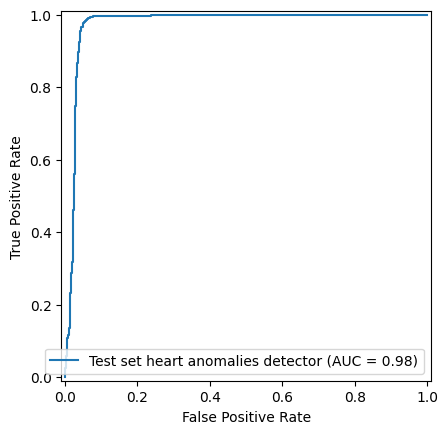

In [65]:
# ROC AUC for train set
fpr, tpr, thresholds = roc_curve(labels_test, test_re_combined)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="Test set heart anomalies detector").plot()

#### Summary:

The metrics of the final model are great. Based on test set model acquired 0.958 accuracy, 0.99 recall, 0.91 precission and 0.98 auc score. 

Given this this might be clinicly useful model. The main goal is to maximize recall for this context of the task, minimazing the chance of missing patient with real HR anomaly. 
Due to used dropout layers the model avoids overfitting and works well both on train and test set. I primarly tested 3 values of dropout layers (0.05, 0.1, 0.2) and i picked 0.05.
Higher dropout means more regularization means slower convergence. Higher loss, but then less gap between train and test set.
Lower dropout is reversed, less regularization, faster convergence. I picked 0.05 as training curves are looking very 'clean' and model does not overfits.
I tried 3 optimizers, AdamMax got me the worst results, and I dropped it almost immediately due to poor convergence. RMSPROP and AdamW had similar results and I sticked with AdamW as the final training curves were slightly better.